# Pipeline Pengolahan Data Obat BPOM

Notebook ini membersihkan data obat BPOM, membuat fitur analitik, menjalankan EDA, dan mengekspor beberapa versi dataset:

- data lengkap setelah cleaning,
- data deduplikasi per nomor registrasi,
- data representatif dengan aturan `1 komposisi = 1 merek/produk`,
- daftar produk yang dihapus karena komposisinya sudah diwakili produk lain.

Catatan: kolom `Merk` pada data mentah hanya berisi `-`, sehingga notebook ini memakai `Nama Produk` sebagai representasi merek/brand.


## 1. Setup dan Import Library


In [ ]:
import html
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

BASE_DIR = Path("..")
DATA_INPUT_PATH = BASE_DIR / "data_mentah" / "obat_bpom_all_data.csv"
DATA_OUTPUT_DIR = BASE_DIR / "data_output" / "processed"
DATA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TOP_N = 15

print("Library berhasil dimuat.")


Library berhasil dimuat.


## 2. Load dan Profiling Data Awal


In [ ]:
raw_drug_data = pd.read_csv(DATA_INPUT_PATH)

print(f"Shape: {raw_drug_data.shape[0]:,} baris x {raw_drug_data.shape[1]} kolom")
print(f"Kolom: {raw_drug_data.columns.tolist()}")

raw_drug_data.head()


Shape: 23,682 baris x 11 kolom
Kolom: ['No', 'Nomor Registrasi', 'Nama Produk', 'Merk', 'Komposisi', 'Bentuk Sediaan', 'Kemasan', 'Pendaftar', 'Tanggal Terbit', 'Masa Berlaku s/d', 'Status']


,No,Nomor Registrasi,Nama Produk,Merk,Komposisi,Bentuk Sediaan,Kemasan,Pendaftar,Tanggal Terbit,Masa Berlaku s/d,Status
0,1,DTL1840403510A1,DIMETIC,-,DIMENHYDRINATE,TABLET,"DUS, 2 BLISTER @ 10 TABLET",PRIMA MEDIKA LABORATORIES - Indonesia,2026-05-05,2027-05-31,Berlaku
1,2,DKL1415715709A1,AZTERCON,-,AZITHROMYCIN DIHYDRATE,KAPLET SALUT SELAPUT,"DUS, 10 BLISTER @ 3 KAPLET SALUT SELAPUT",ETERCON PHARMA - Indonesia,2026-05-05,2031-05-05,Berlaku
2,3,DBL8305501304A1,DUMIN,-,PARACETAMOL,KAPLET,"DUS, 10 BLISTER @ 10 KAPLET",ACTAVIS INDONESIA - Indonesia,2026-05-05,2031-05-05,Berlaku
3,4,GKL2632724717B1,LEVETIRACETAM,-,LEVETIRACETAM,TABLET SALUT SELAPUT,"DUS, 3 BLISTER @ 10 TABLET SALUT SELAPUT",YARINDO FARMATAMA - Indonesia,2026-05-05,2031-05-05,Berlaku
4,5,DKL2128209617B1,MAXLIS 20,-,TADALAFIL,TABLET SALUT SELAPUT,"DUS, 1 STRIP @ 4 TABLET SALUT SELAPUT",SIMEX PHARMACEUTICAL INDONESIA - Indonesia,2026-05-05,2031-03-23,Berlaku


In [ ]:
def summarize_columns(data: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "dtype": data.dtypes.astype(str),
            "null_count": data.isna().sum(),
            "null_percent": (data.isna().mean() * 100).round(2),
            "unique_count": data.nunique(dropna=True),
        }
    )


initial_profile = summarize_columns(raw_drug_data)
initial_profile


,dtype,null_count,null_percent,unique_count
No,int64,0,0.00,23682
Nomor Registrasi,object,0,0.00,15085
Nama Produk,object,0,0.00,9167
Merk,object,0,0.00,1
Komposisi,object,4346,18.35,2477
Bentuk Sediaan,object,0,0.00,4975
Kemasan,object,0,0.00,3164
Pendaftar,object,0,0.00,208
Tanggal Terbit,object,0,0.00,1348
Masa Berlaku s/d,object,0,0.00,1915


In [ ]:
print("Distribusi Status:")
display(raw_drug_data["Status"].value_counts().to_frame("Jumlah"))

print("Nilai unik kolom Merk:")
display(raw_drug_data["Merk"].value_counts(dropna=False).to_frame("Jumlah"))


Distribusi Status:


,Jumlah
Status,
Berlaku,23105
Berlaku (Khusus Ekspor),577


Nilai unik kolom Merk:


,Jumlah
Merk,
-,23682


## 3. Data Cleaning


In [ ]:
drug_data = raw_drug_data.copy()

redundant_columns = ["No", "Merk"]
drug_data = drug_data.drop(columns=redundant_columns)

print(f"Kolom dihapus: {redundant_columns}")
print(f"Shape setelah drop kolom: {drug_data.shape}")


Kolom dihapus: ['No', 'Merk']
Shape setelah drop kolom: (23682, 9)


### 3.2 Membersihkan HTML Entities di Komposisi


In [ ]:
dirty_composition_sample = drug_data[
    drug_data["Komposisi"].str.contains("&lt;br&gt;", na=False)
].head(3)

dirty_composition_sample[["Nama Produk", "Komposisi"]]


,Nama Produk,Komposisi
10,PIMAG,DRIED ALUMINIUM HYDROXIDE GEL&lt;br&gt;MAGNESIUM HYDROXIDE&lt;br&gt;SIMETHICONE EMULSION 30
15,DEXAMINE,DEXAMETHASONE SODIUM PHOSPHATE&lt;br&gt;DEXCHLORPHENIRAMINE MALEATE
18,KONIDIN BATUK &amp; FLU (RASA JAHE),DEXTROMETHORPHAN HYDROBROMIDE&lt;br&gt;GUAIFENESIN&lt;br&gt;PARACETAMOL&lt;br&gt;PSEUDOEPHEDRINE...


In [ ]:
def clean_composition_text(value: str) -> str:
    if pd.isna(value):
        return value

    unescaped_value = html.unescape(value)
    value_with_separator = re.sub(
        pattern=r"<br\s*/?>",
        repl=" | ",
        string=unescaped_value,
        flags=re.IGNORECASE,
    )
    return re.sub(r"\s+", " ", value_with_separator).strip()


drug_data["Komposisi"] = drug_data["Komposisi"].apply(clean_composition_text)

drug_data.loc[dirty_composition_sample.index, ["Nama Produk", "Komposisi"]]


,Nama Produk,Komposisi
10,PIMAG,DRIED ALUMINIUM HYDROXIDE GEL | MAGNESIUM HYDROXIDE | SIMETHICONE EMULSION 30
15,DEXAMINE,DEXAMETHASONE SODIUM PHOSPHATE | DEXCHLORPHENIRAMINE MALEATE
18,KONIDIN BATUK &amp; FLU (RASA JAHE),DEXTROMETHORPHAN HYDROBROMIDE | GUAIFENESIN | PARACETAMOL | PSEUDOEPHEDRINE HYDROCHLORIDE


### 3.3 Membersihkan Nama Produk


In [ ]:
def clean_product_name(value: str) -> str:
    if pd.isna(value):
        return value

    unescaped_value = html.unescape(value)
    return re.sub(r"\s+", " ", unescaped_value).strip()


drug_data["Nama Produk"] = drug_data["Nama Produk"].apply(clean_product_name)

print("Nama Produk selesai dibersihkan.")


Nama Produk selesai dibersihkan.

### 3.4 Konversi Tipe Data Tanggal


In [ ]:
date_columns = ["Tanggal Terbit", "Masa Berlaku s/d"]

for column in date_columns:
    drug_data[column] = pd.to_datetime(drug_data[column], errors="coerce")

date_null_summary = drug_data[date_columns].isna().sum().to_frame("Null")
display(date_null_summary)

print(f"Range Tanggal Terbit: {drug_data['Tanggal Terbit'].min()} sampai {drug_data['Tanggal Terbit'].max()}")
print(f"Range Masa Berlaku: {drug_data['Masa Berlaku s/d'].min()} sampai {drug_data['Masa Berlaku s/d'].max()}")


,Null
Tanggal Terbit,0
Masa Berlaku s/d,0


Range Tanggal Terbit: 2018-03-05 00:00:00 sampai 2026-05-05 00:00:00
Range Masa Berlaku: 2024-05-07 00:00:00 sampai 2031-05-05 00:00:00


### 3.5 Parsing Pendaftar


In [ ]:
def split_registrant(value: str) -> tuple[str, str | None]:
    if pd.isna(value):
        return value, None

    parts = value.rsplit(" - ", 1)
    if len(parts) == 2:
        return parts[0].strip(), parts[1].strip()

    return value.strip(), None


drug_data[["Perusahaan", "Negara_Asal"]] = drug_data["Pendaftar"].apply(
    lambda value: pd.Series(split_registrant(value))
)

print(f"Jumlah perusahaan unik: {drug_data['Perusahaan'].nunique():,}")
display(drug_data["Negara_Asal"].value_counts(dropna=False).to_frame("Jumlah"))


Jumlah perusahaan unik: 207


,Jumlah
Negara_Asal,
Indonesia,23674
Japan,5
None,3


## 4. Feature Engineering


In [ ]:
DRUG_CATEGORY_MAP = {
    "DKL": "Obat Keras - Lokal",
    "DKI": "Obat Keras - Impor",
    "GKL": "Obat Generik Keras - Lokal",
    "DTL": "Obat Bebas Terbatas - Lokal",
    "DTI": "Obat Bebas Terbatas - Impor",
    "DBL": "Obat Bebas - Lokal",
    "DBI": "Obat Bebas - Impor",
    "DPL": "Psikotropika - Lokal",
    "DPI": "Psikotropika - Impor",
    "DNL": "Narkotika - Lokal",
    "DNI": "Narkotika - Impor",
    "GBL": "Obat Generik Bebas - Lokal",
    "GTL": "Obat Generik Bebas Terbatas - Lokal",
    "GPL": "Obat Generik Psikotropika - Lokal",
    "GNL": "Obat Generik Narkotika - Lokal",
    "LKE": "Lisensi - Khusus Ekspor",
    "IKE": "Impor - Khusus Ekspor",
    "EUA": "Emergency Use Authorization",
}


def map_drug_group(registration_prefix: str) -> str:
    hard_drug_prefixes = {"DKL", "DKI", "GKL"}
    limited_free_prefixes = {"DTL", "DTI", "GTL"}
    free_drug_prefixes = {"DBL", "DBI", "GBL"}
    psychotropic_prefixes = {"DPL", "DPI", "GPL"}
    narcotic_prefixes = {"DNL", "DNI", "GNL"}

    if registration_prefix in hard_drug_prefixes:
        return "Obat Keras"
    if registration_prefix in limited_free_prefixes:
        return "Obat Bebas Terbatas"
    if registration_prefix in free_drug_prefixes:
        return "Obat Bebas"
    if registration_prefix in psychotropic_prefixes:
        return "Psikotropika"
    if registration_prefix in narcotic_prefixes:
        return "Narkotika"
    if registration_prefix in {"LKE", "IKE"}:
        return "Khusus Ekspor"
    if registration_prefix == "EUA":
        return "EUA"

    return "Lainnya"


def map_drug_origin(registration_prefix: str) -> str:
    if registration_prefix.endswith("I"):
        return "Impor"
    if registration_prefix.endswith("L") or registration_prefix in {"LKE", "IKE", "EUA"}:
        return "Lokal/Lainnya"

    return "Lainnya"


drug_data["Prefix_Registrasi"] = drug_data["Nomor Registrasi"].str[:3].str.upper()
drug_data["Kategori_Obat"] = (
    drug_data["Prefix_Registrasi"].map(DRUG_CATEGORY_MAP).fillna("Lainnya")
)
drug_data["Golongan_Obat"] = drug_data["Prefix_Registrasi"].apply(map_drug_group)
drug_data["Asal_Obat"] = drug_data["Prefix_Registrasi"].apply(map_drug_origin)

display(drug_data["Golongan_Obat"].value_counts().to_frame("Jumlah"))


,Jumlah
Golongan_Obat,
Obat Keras,18583
Obat Bebas Terbatas,2369
Obat Bebas,1323
Khusus Ekspor,1026
Psikotropika,231
EUA,79
Narkotika,71


### 4.2 Parsing Komposisi Menjadi List Zat Aktif


In [ ]:
def extract_active_ingredients(composition: str) -> list[str]:
    if pd.isna(composition):
        return []

    active_ingredients = []
    for ingredient in composition.split("|"):
        cleaned_ingredient = re.sub(r"^KOMBINASI-", "", ingredient).strip()
        if cleaned_ingredient:
            active_ingredients.append(cleaned_ingredient)

    return active_ingredients


drug_data["List_Zat_Aktif"] = drug_data["Komposisi"].apply(extract_active_ingredients)
drug_data["Jumlah_Zat_Aktif"] = drug_data["List_Zat_Aktif"].apply(len)

display(drug_data["Jumlah_Zat_Aktif"].describe().to_frame("Statistik"))

complex_composition_sample = drug_data.nlargest(5, "Jumlah_Zat_Aktif")[
    ["Nama Produk", "Jumlah_Zat_Aktif", "Komposisi"]
]
complex_composition_sample


,Statistik
count,23682.000000
mean,0.962545
std,0.999890
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,27.000000


,Nama Produk,Jumlah_Zat_Aktif,Komposisi
4828,SMOFKABIVEN,27,ALANINE | CALCIUM CHLORIDE DIHYDRATE | DEXTROSE MONOHYDRATE | GLYCINE | HISTIDINE | ISOLEUCINE |...
6216,SMOFKABIVEN PERIPHERAL,27,ALANINE | ARGININE | CALCIUM CHLORIDE DIHYDRATE | DEXTROSE MONOHYDRATE | GLYCINE | HISTIDINE | I...
6221,SMOFKABIVEN PERIPHERAL,27,ALANINE | ARGININE | CALCIUM CHLORIDE DIHYDRATE | DEXTROSE MONOHYDRATE | GLYCINE | HISTIDINE | I...
4056,BENUTRION VE,24,ACETYLCYSTEINE | ACETYLTYROSINE | ALANINE | ASPARTIC ACID | CALCIUM CHLORIDE DIHYDRATE | GLUTAMI...
20033,BENUTRION VE,24,ACETYLCYSTEINE | ACETYLTYROSINE | ALANINE | ASPARTIC ACID | CALCIUM CHLORIDE DIHYDRATE | GLUTAMI...


### 4.3 Durasi Registrasi dan Status Kedaluwarsa


In [ ]:
drug_data["Durasi_Registrasi_Hari"] = (
    drug_data["Masa Berlaku s/d"] - drug_data["Tanggal Terbit"]
).dt.days
drug_data["Durasi_Registrasi_Tahun"] = (
    drug_data["Durasi_Registrasi_Hari"] / 365.25
).round(1)

today = pd.Timestamp.now().normalize()
drug_data["Sudah_Kedaluwarsa"] = drug_data["Masa Berlaku s/d"] < today
drug_data["Sisa_Hari_Berlaku"] = (drug_data["Masa Berlaku s/d"] - today).dt.days

print(f"Durasi registrasi rata-rata: {drug_data['Durasi_Registrasi_Tahun'].mean():.1f} tahun")
print(f"Obat sudah kedaluwarsa: {drug_data['Sudah_Kedaluwarsa'].sum():,}")
print(f"Obat masih berlaku: {(~drug_data['Sudah_Kedaluwarsa']).sum():,}")


Durasi registrasi rata-rata: 4.5 tahun
Obat sudah kedaluwarsa: 7,606
Obat masih berlaku: 16,076


### 4.4 Analisis Duplikasi Nomor Registrasi


In [ ]:
registration_counts = drug_data["Nomor Registrasi"].value_counts()
duplicated_registrations = registration_counts[registration_counts > 1]

print(f"Total nomor registrasi unik: {registration_counts.shape[0]:,}")
print(f"Nomor registrasi dengan lebih dari satu entry: {duplicated_registrations.shape[0]:,}")
print(f"Entry terbanyak dalam satu nomor registrasi: {duplicated_registrations.max():,}")

sample_registration_number = duplicated_registrations.index[0]
drug_data.loc[
    drug_data["Nomor Registrasi"] == sample_registration_number,
    ["Nama Produk", "Kemasan", "Bentuk Sediaan"],
].head()


Total nomor registrasi unik: 15,085
Nomor registrasi dengan lebih dari satu entry: 6,001
Entry terbanyak dalam satu nomor registrasi: 19


,Nama Produk,Kemasan,Bentuk Sediaan
433,ARCOXIA,"DUS, 10 BLISTER @ 10 TABLET SALUT SELAPUT",TABLET SALUT SELAPUT
437,ARCOXIA,"DUS, 6 BLISTER @ 5 TABLET SALUT SELAPUT",TABLET SALUT SELAPUT
438,ARCOXIA,"DRUM, MAKSIMUM @ 30 KG",TABLET SALUT SELAPUT
439,ARCOXIA,"DUS, 3 BLISTER @ 10 TABLET SALUT SELAPUT",TABLET SALUT SELAPUT
442,ARCOXIA,"DUS, 4 BLISTER @ 7 TABLET SALUT SELAPUT",TABLET SALUT SELAPUT


## 5. Exploratory Data Analysis


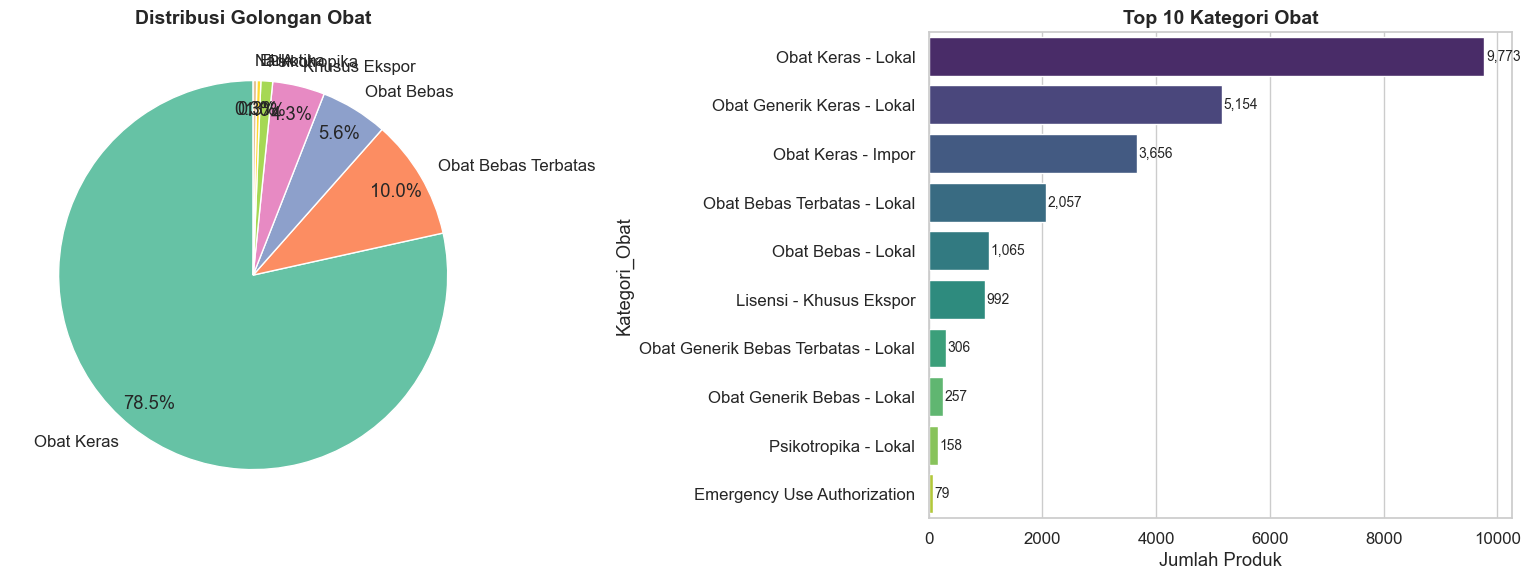

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

drug_group_counts = drug_data["Golongan_Obat"].value_counts()
pie_colors = sns.color_palette("Set2", len(drug_group_counts))
axes[0].pie(
    drug_group_counts.values,
    labels=drug_group_counts.index,
    autopct="%1.1f%%",
    colors=pie_colors,
    startangle=90,
    pctdistance=0.85,
)
axes[0].set_title("Distribusi Golongan Obat", fontsize=14, fontweight="bold")

top_drug_categories = drug_data["Kategori_Obat"].value_counts().head(10)
sns.barplot(
    x=top_drug_categories.values,
    y=top_drug_categories.index,
    ax=axes[1],
    palette="viridis",
)
axes[1].set_xlabel("Jumlah Produk")
axes[1].set_title("Top 10 Kategori Obat", fontsize=14, fontweight="bold")

for index, value in enumerate(top_drug_categories.values):
    axes[1].text(value + 30, index, f"{value:,}", va="center", fontsize=10)

plt.tight_layout()
plt.savefig(DATA_OUTPUT_DIR / "distribusi_golongan_obat.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.2 Top Perusahaan Farmasi


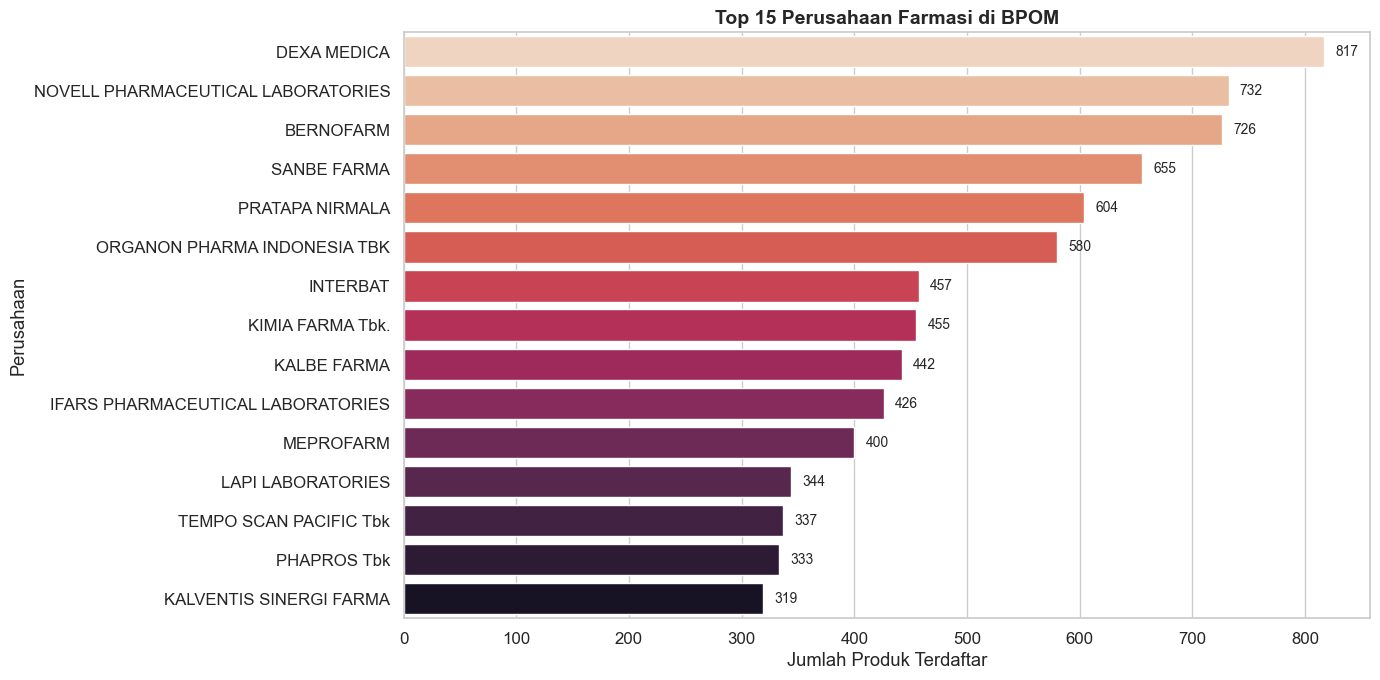

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

top_companies = drug_data["Perusahaan"].value_counts().head(TOP_N)
sns.barplot(x=top_companies.values, y=top_companies.index, palette="rocket_r", ax=ax)
ax.set_xlabel("Jumlah Produk Terdaftar")
ax.set_title("Top 15 Perusahaan Farmasi di BPOM", fontsize=14, fontweight="bold")

for index, value in enumerate(top_companies.values):
    ax.text(value + 10, index, f"{value:,}", va="center", fontsize=10)

plt.tight_layout()
plt.savefig(DATA_OUTPUT_DIR / "top_perusahaan_farmasi.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.3 Distribusi Bentuk Sediaan


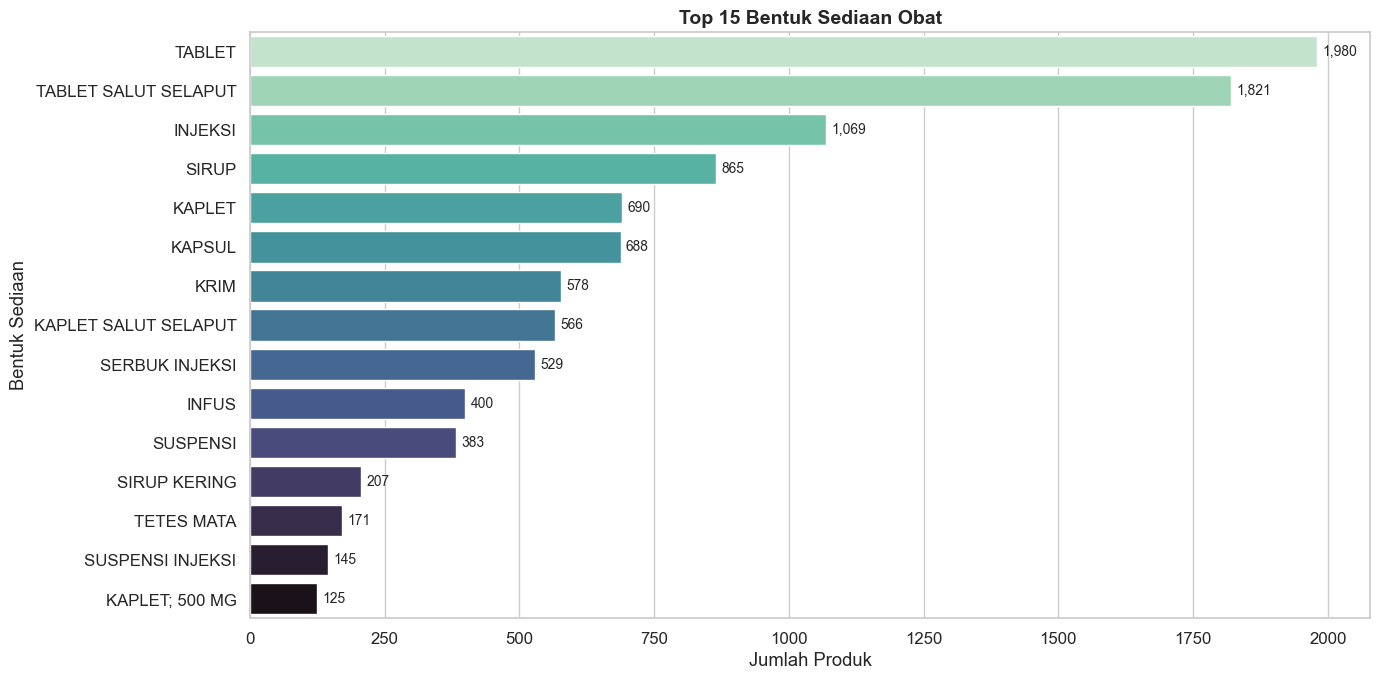

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

top_dosage_forms = drug_data["Bentuk Sediaan"].value_counts().head(TOP_N)
sns.barplot(
    x=top_dosage_forms.values,
    y=top_dosage_forms.index,
    palette="mako_r",
    ax=ax,
)
ax.set_xlabel("Jumlah Produk")
ax.set_title("Top 15 Bentuk Sediaan Obat", fontsize=14, fontweight="bold")

for index, value in enumerate(top_dosage_forms.values):
    ax.text(value + 10, index, f"{value:,}", va="center", fontsize=10)

plt.tight_layout()
plt.savefig(DATA_OUTPUT_DIR / "distribusi_bentuk_sediaan.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.4 Tren Registrasi Obat per Tahun


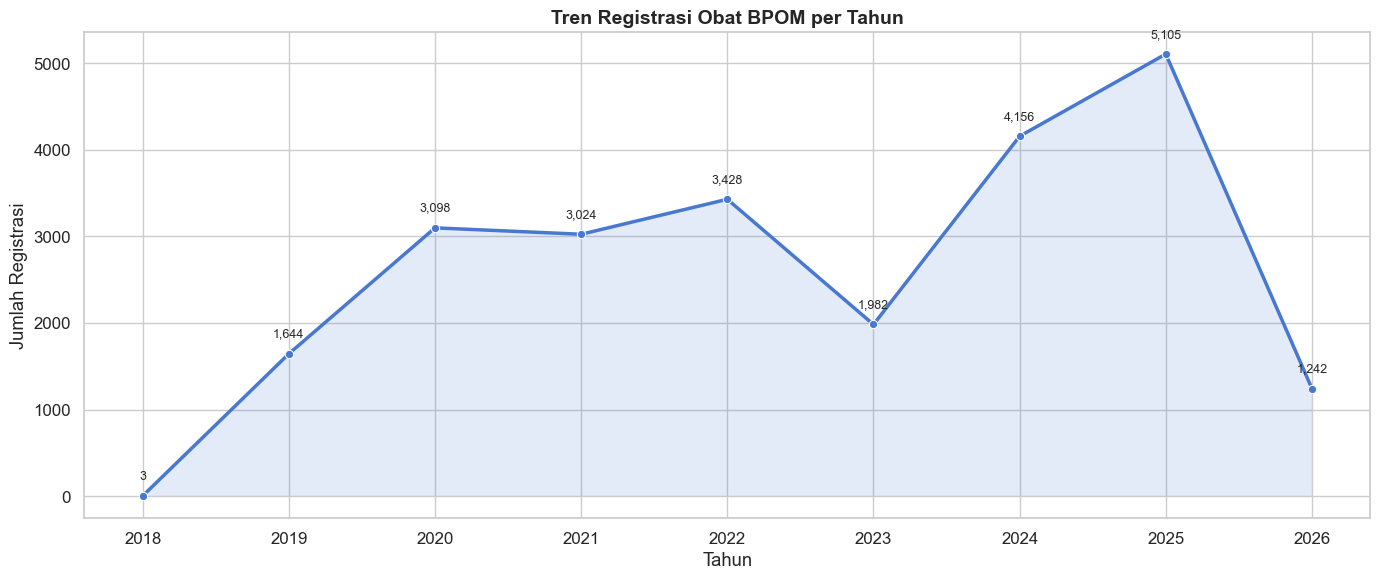

In [ ]:
drug_data["Tahun_Terbit"] = drug_data["Tanggal Terbit"].dt.year
yearly_registration_counts = (
    drug_data.groupby("Tahun_Terbit")
    .size()
    .reset_index(name="Jumlah")
    .dropna(subset=["Tahun_Terbit"])
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(
    data=yearly_registration_counts,
    x="Tahun_Terbit",
    y="Jumlah",
    marker="o",
    linewidth=2.5,
    ax=ax,
)
ax.fill_between(
    yearly_registration_counts["Tahun_Terbit"],
    yearly_registration_counts["Jumlah"],
    alpha=0.15,
)
ax.set_xlabel("Tahun")
ax.set_ylabel("Jumlah Registrasi")
ax.set_title("Tren Registrasi Obat BPOM per Tahun", fontsize=14, fontweight="bold")

for _, row in yearly_registration_counts.iterrows():
    ax.annotate(
        f"{row['Jumlah']:,}",
        (row["Tahun_Terbit"], row["Jumlah"]),
        textcoords="offset points",
        xytext=(0, 12),
        ha="center",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig(DATA_OUTPUT_DIR / "tren_registrasi_per_tahun.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.5 Top Zat Aktif Paling Sering Digunakan


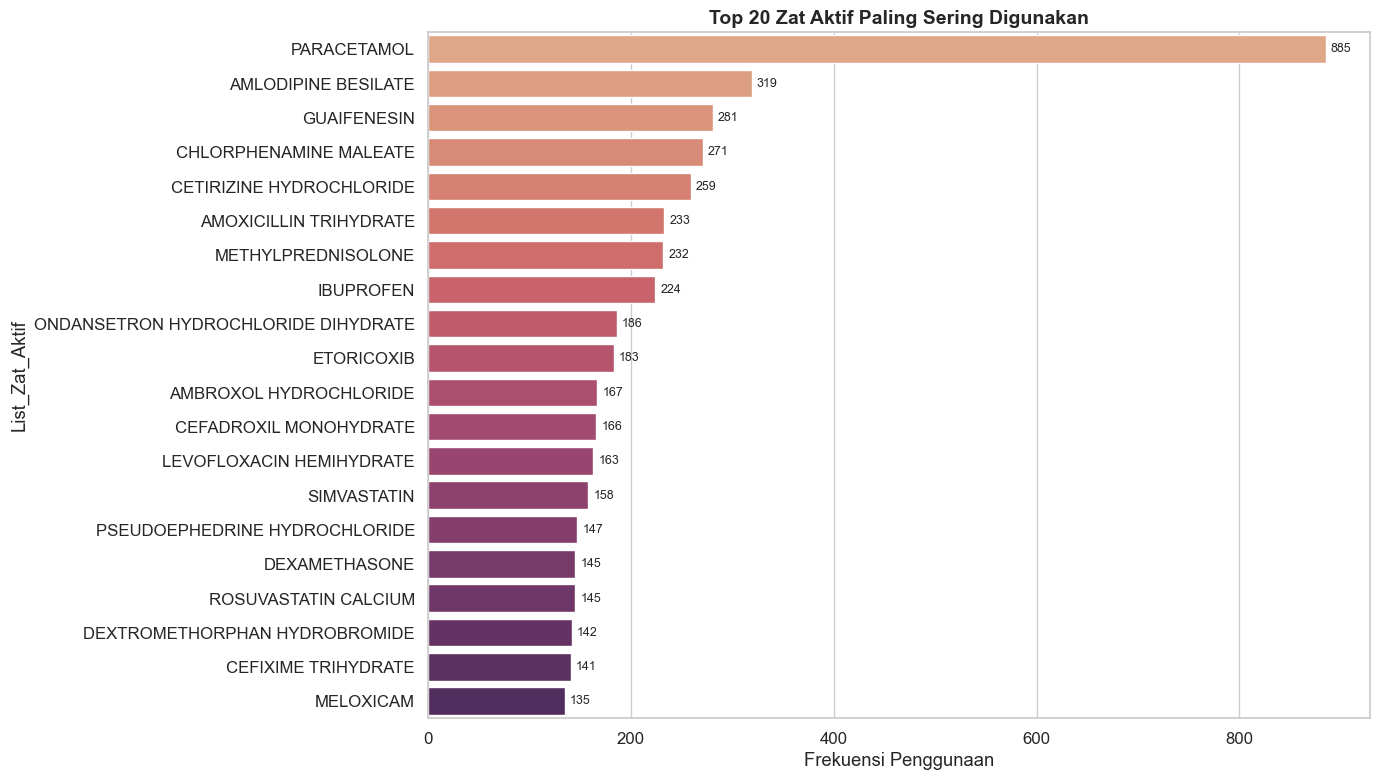

In [ ]:
all_active_ingredients = drug_data["List_Zat_Aktif"].explode()
all_active_ingredients = all_active_ingredients[all_active_ingredients.str.len() > 0]
top_active_ingredients = all_active_ingredients.value_counts().head(20)

fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(
    x=top_active_ingredients.values,
    y=top_active_ingredients.index,
    palette="flare",
    ax=ax,
)
ax.set_xlabel("Frekuensi Penggunaan")
ax.set_title("Top 20 Zat Aktif Paling Sering Digunakan", fontsize=14, fontweight="bold")

for index, value in enumerate(top_active_ingredients.values):
    ax.text(value + 5, index, f"{value:,}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(DATA_OUTPUT_DIR / "top_zat_aktif.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.6 Distribusi Jumlah Zat Aktif per Obat


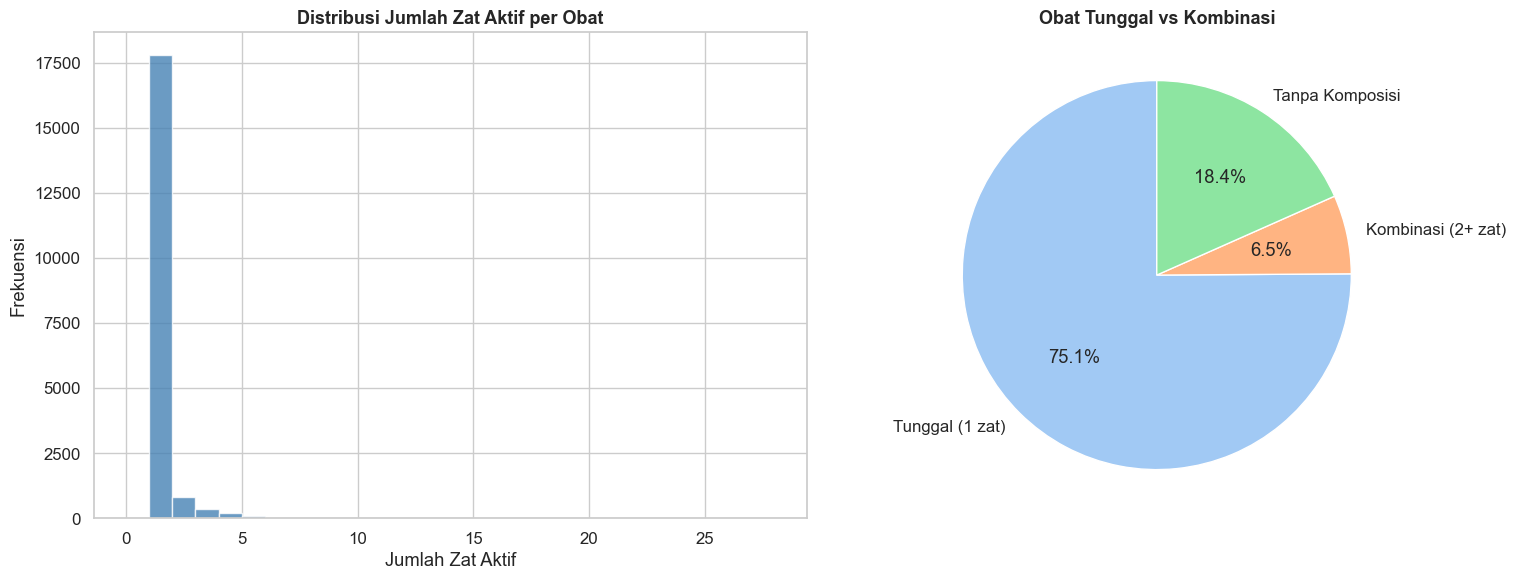

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

positive_ingredient_counts = drug_data.loc[
    drug_data["Jumlah_Zat_Aktif"] > 0,
    "Jumlah_Zat_Aktif",
]
positive_ingredient_counts.hist(
    bins=range(0, drug_data["Jumlah_Zat_Aktif"].max() + 2),
    ax=axes[0],
    color="steelblue",
    edgecolor="white",
    alpha=0.8,
)
axes[0].set_xlabel("Jumlah Zat Aktif")
axes[0].set_ylabel("Frekuensi")
axes[0].set_title("Distribusi Jumlah Zat Aktif per Obat", fontsize=13, fontweight="bold")

single_vs_combination = pd.Series(
    {
        "Tunggal (1 zat)": (drug_data["Jumlah_Zat_Aktif"] == 1).sum(),
        "Kombinasi (2+ zat)": (drug_data["Jumlah_Zat_Aktif"] >= 2).sum(),
        "Tanpa Komposisi": (drug_data["Jumlah_Zat_Aktif"] == 0).sum(),
    }
)
single_vs_combination.plot.pie(
    autopct="%1.1f%%",
    ax=axes[1],
    colors=sns.color_palette("pastel", 3),
    startangle=90,
)
axes[1].set_ylabel("")
axes[1].set_title("Obat Tunggal vs Kombinasi", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(DATA_OUTPUT_DIR / "distribusi_zat_aktif.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Deduplikasi dan Transformasi Dataset


### 6.1 Deduplikasi Nomor Registrasi


In [ ]:
def join_unique_values(values: pd.Series) -> str:
    unique_values = values.dropna().astype(str).drop_duplicates()
    return " ;; ".join(unique_values)


registration_aggregation = {
    "Nama Produk": "first",
    "Komposisi": "first",
    "Bentuk Sediaan": "first",
    "Kemasan": join_unique_values,
    "Pendaftar": "first",
    "Perusahaan": "first",
    "Negara_Asal": "first",
    "Tanggal Terbit": "first",
    "Masa Berlaku s/d": "first",
    "Status": "first",
    "Kategori_Obat": "first",
    "Golongan_Obat": "first",
    "Asal_Obat": "first",
    "Jumlah_Zat_Aktif": "first",
    "Durasi_Registrasi_Tahun": "first",
    "Sudah_Kedaluwarsa": "first",
    "Sisa_Hari_Berlaku": "first",
    "List_Zat_Aktif": "first",
}

deduplicated_registration_data = (
    drug_data.groupby("Nomor Registrasi", as_index=False)
    .agg(registration_aggregation)
)

packaging_variant_counts = drug_data.groupby("Nomor Registrasi")["Kemasan"].nunique()
deduplicated_registration_data["Jumlah_Varian_Kemasan"] = (
    deduplicated_registration_data["Nomor Registrasi"].map(packaging_variant_counts)
)

print(f"Data sebelum deduplikasi registrasi: {drug_data.shape[0]:,} baris")
print(f"Data sesudah deduplikasi registrasi: {deduplicated_registration_data.shape[0]:,} baris")


Data sebelum deduplikasi registrasi: 23,682 baris
Data sesudah deduplikasi registrasi: 15,085 baris


### 6.2 Transformasi `1 Komposisi = 1 Merek/Produk`

Tujuan transformasi ini adalah membuat satu komposisi hanya diwakili oleh satu produk. Karena kolom `Merk` tidak informatif, `Nama Produk` digunakan sebagai merek/brand.

Aturan pemilihan produk yang dipertahankan:

1. utamakan data yang belum kedaluwarsa,
2. pilih tanggal masa berlaku paling panjang,
3. pilih tanggal terbit paling baru,
4. pilih produk dengan varian kemasan terbanyak,
5. jika masih sama, pilih nama produk paling awal secara alfabetis.


In [ ]:
def normalize_ingredient_name(value: str) -> str:
    cleaned_value = re.sub(r"\s+", " ", str(value).upper()).strip()
    return re.sub(r"[^A-Z0-9%.,/+\- ]", "", cleaned_value)


def build_composition_key(active_ingredients: list[str], composition: str) -> str:
    if active_ingredients:
        normalized_ingredients = {
            normalize_ingredient_name(ingredient)
            for ingredient in active_ingredients
            if normalize_ingredient_name(ingredient)
        }
        return " | ".join(sorted(normalized_ingredients))

    if pd.isna(composition):
        return "TANPA KOMPOSISI"

    return normalize_ingredient_name(composition)


deduplicated_registration_data["Komposisi_Normalized"] = deduplicated_registration_data.apply(
    lambda row: build_composition_key(
        active_ingredients=row["List_Zat_Aktif"],
        composition=row["Komposisi"],
    ),
    axis=1,
)

composition_brand_counts = (
    deduplicated_registration_data.groupby("Komposisi_Normalized")["Nama Produk"]
    .nunique()
    .sort_values(ascending=False)
)

print(f"Total komposisi unik: {composition_brand_counts.shape[0]:,}")
print(f"Komposisi dengan lebih dari satu produk: {(composition_brand_counts > 1).sum():,}")
display(composition_brand_counts.head(10).to_frame("Jumlah_Produk"))


Total komposisi unik: 2,173


Komposisi dengan lebih dari satu produk: 971


,Jumlah_Produk
Komposisi_Normalized,
TANPA KOMPOSISI,1487
PARACETAMOL,169
METHYLPREDNISOLONE,95
AMLODIPINE BESILATE,87
AMOXICILLIN TRIHYDRATE,84
IBUPROFEN,75
CETIRIZINE HYDROCHLORIDE,75
CEFADROXIL MONOHYDRATE,61
MEFENAMIC ACID,61


In [ ]:
selection_columns = [
    "Komposisi_Normalized",
    "Sudah_Kedaluwarsa",
    "Masa Berlaku s/d",
    "Tanggal Terbit",
    "Jumlah_Varian_Kemasan",
    "Nama Produk",
]

ranked_composition_data = deduplicated_registration_data.sort_values(
    by=selection_columns,
    ascending=[True, True, False, False, False, True],
    na_position="last",
)

one_brand_per_composition_data = ranked_composition_data.drop_duplicates(
    subset="Komposisi_Normalized",
    keep="first",
).sort_values("Nama Produk")

removed_composition_duplicate_data = ranked_composition_data[
    ~ranked_composition_data["Nomor Registrasi"].isin(
        one_brand_per_composition_data["Nomor Registrasi"]
    )
].copy()

removed_composition_duplicate_data["Alasan_Dihapus"] = (
    "Komposisi sudah diwakili oleh produk lain"
)

print(f"Data dedup registrasi: {deduplicated_registration_data.shape[0]:,} baris")
print(f"Data 1 komposisi = 1 produk: {one_brand_per_composition_data.shape[0]:,} baris")
print(f"Produk/merek dihapus: {removed_composition_duplicate_data.shape[0]:,} baris")


Data dedup registrasi: 15,085 baris
Data 1 komposisi = 1 produk: 2,173 baris
Produk/merek dihapus: 12,912 baris


### 6.3 Visualisasi Hasil Transformasi Komposisi


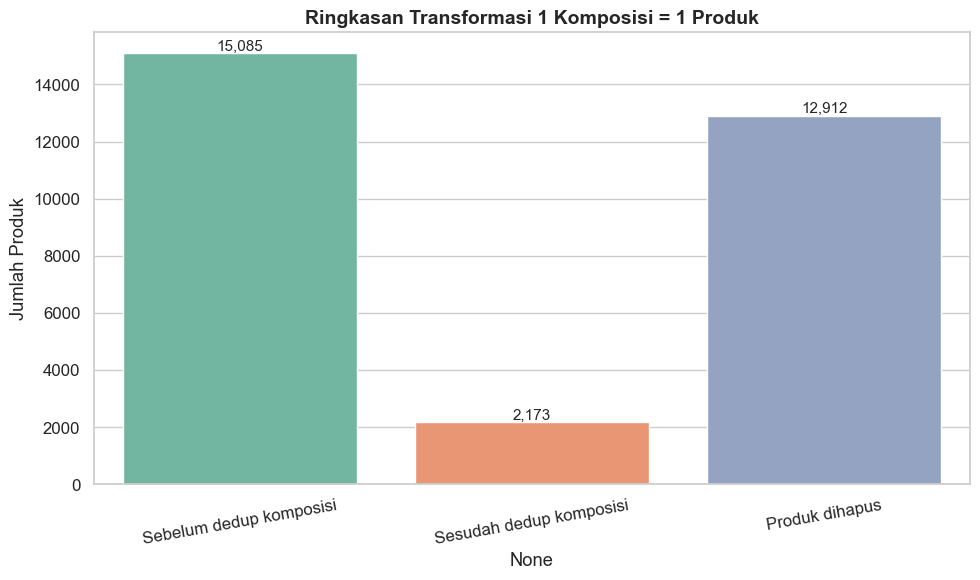

In [ ]:
overview_counts = pd.Series(
    {
        "Sebelum dedup komposisi": deduplicated_registration_data.shape[0],
        "Sesudah dedup komposisi": one_brand_per_composition_data.shape[0],
        "Produk dihapus": removed_composition_duplicate_data.shape[0],
    }
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=overview_counts.index, y=overview_counts.values, palette="Set2", ax=ax)
ax.set_ylabel("Jumlah Produk")
ax.set_title("Ringkasan Transformasi 1 Komposisi = 1 Produk", fontsize=14, fontweight="bold")

for index, value in enumerate(overview_counts.values):
    ax.text(index, value + 100, f"{value:,}", ha="center", fontsize=11)

plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig(DATA_OUTPUT_DIR / "ringkasan_dedup_komposisi.png", dpi=150, bbox_inches="tight")
plt.show()


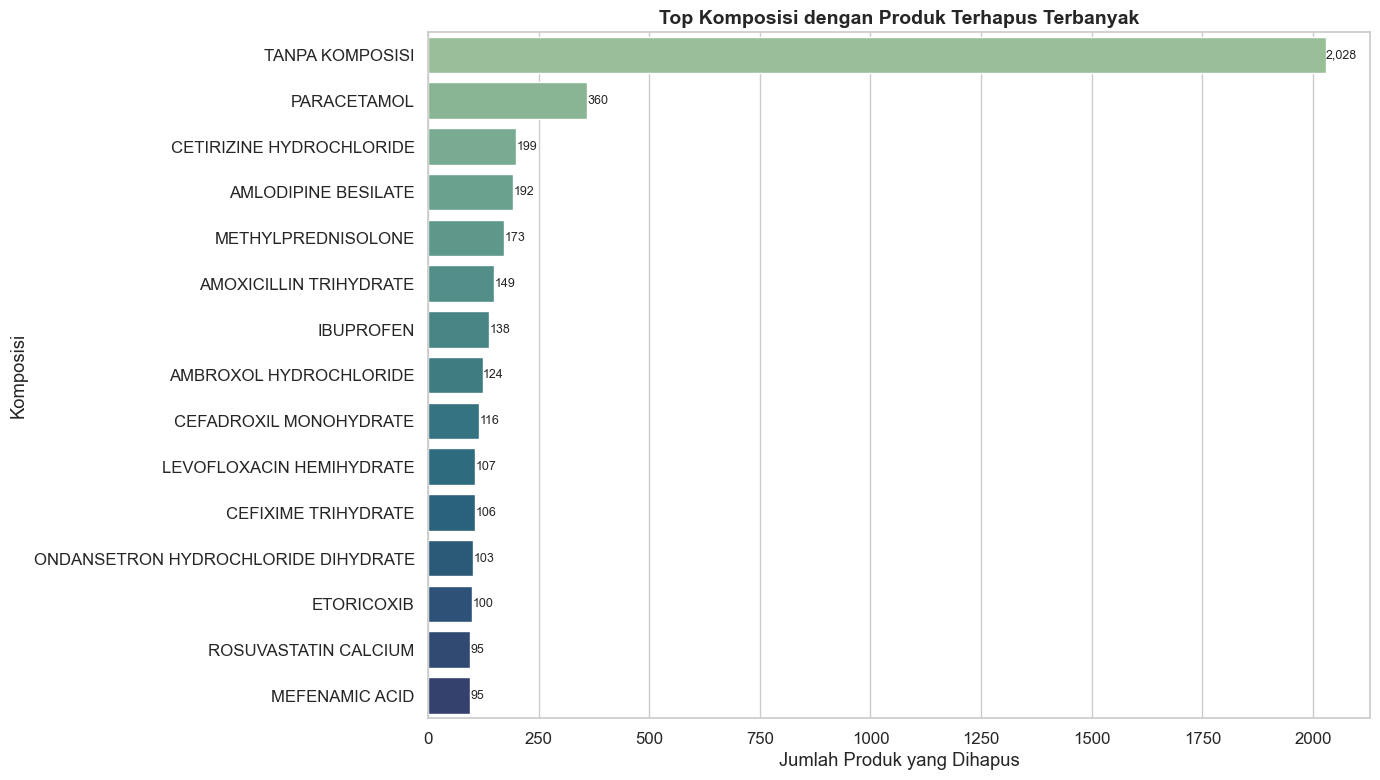

In [ ]:
top_removed_compositions = (
    removed_composition_duplicate_data["Komposisi_Normalized"]
    .value_counts()
    .head(TOP_N)
)

fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(
    x=top_removed_compositions.values,
    y=top_removed_compositions.index,
    palette="crest",
    ax=ax,
)
ax.set_xlabel("Jumlah Produk yang Dihapus")
ax.set_ylabel("Komposisi")
ax.set_title("Top Komposisi dengan Produk Terhapus Terbanyak", fontsize=14, fontweight="bold")

for index, value in enumerate(top_removed_compositions.values):
    ax.text(value + 1, index, f"{value:,}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(DATA_OUTPUT_DIR / "top_komposisi_produk_dihapus.png", dpi=150, bbox_inches="tight")
plt.show()


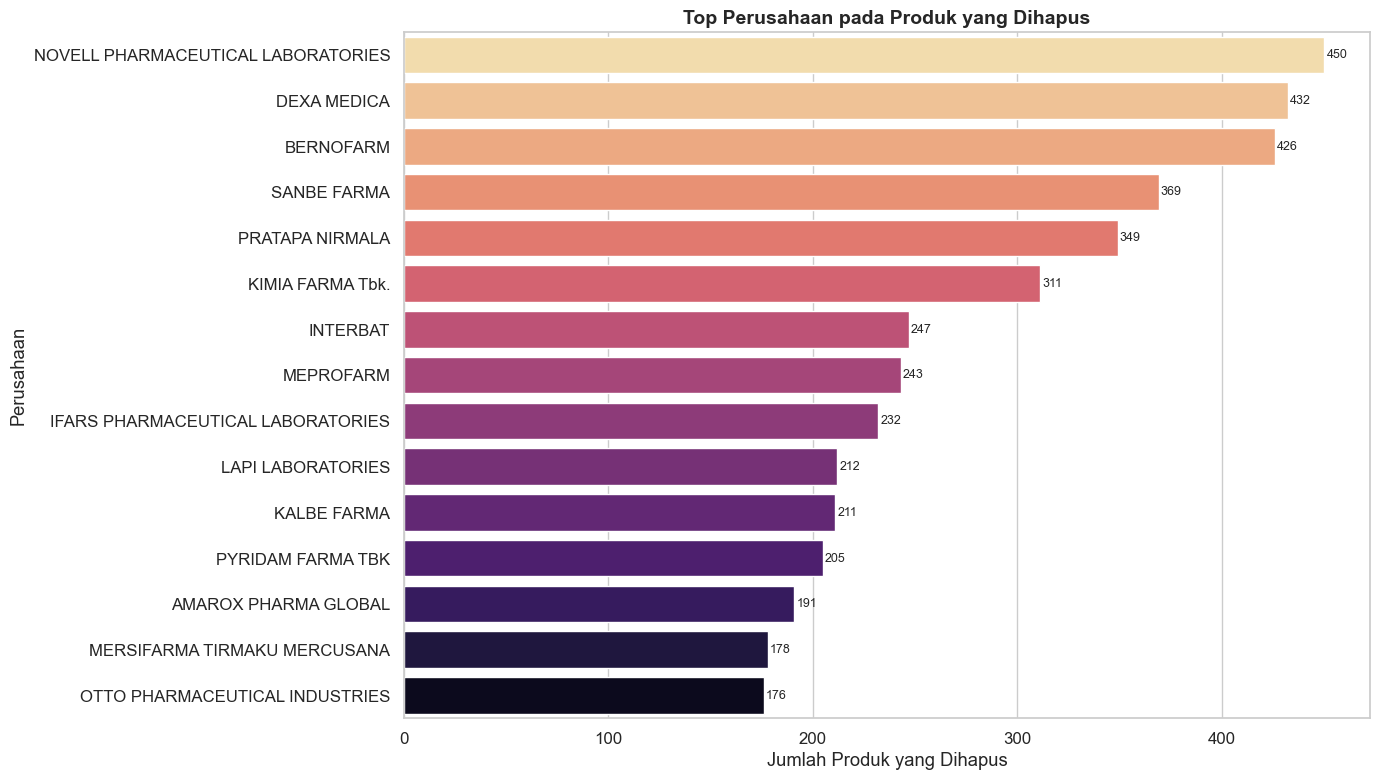

In [ ]:
top_removed_companies = (
    removed_composition_duplicate_data["Perusahaan"]
    .value_counts()
    .head(TOP_N)
)

fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(
    x=top_removed_companies.values,
    y=top_removed_companies.index,
    palette="magma_r",
    ax=ax,
)
ax.set_xlabel("Jumlah Produk yang Dihapus")
ax.set_ylabel("Perusahaan")
ax.set_title("Top Perusahaan pada Produk yang Dihapus", fontsize=14, fontweight="bold")

for index, value in enumerate(top_removed_companies.values):
    ax.text(value + 1, index, f"{value:,}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(DATA_OUTPUT_DIR / "top_perusahaan_produk_dihapus.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.4 Contoh Produk yang Dihapus


In [ ]:
removed_brand_preview_columns = [
    "Nama Produk",
    "Nomor Registrasi",
    "Komposisi",
    "Perusahaan",
    "Bentuk Sediaan",
    "Alasan_Dihapus",
]

removed_brand_preview = removed_composition_duplicate_data[
    removed_brand_preview_columns
].head(25)

removed_brand_preview


,Nama Produk,Nomor Registrasi,Komposisi,Perusahaan,Bentuk Sediaan,Alasan_Dihapus
1135,FLUQUADRI,DKI1616500243B1,A/BRISBANE/02/2018 (H1N1) PDM09 - LIKE VIRUS. A/KANSAS/14/2017 (H3N2) - LIKE VIRUS (A/KANSAS/14/...,KALVENTIS SINERGI FARMA,SUSPENSI INJEKSI; 15 MCG /15 MCG /15 MCG /15 MCG,Komposisi sudah diwakili oleh produk lain
1684,VAXIGRIP TETRA NH,DKI2059703543A1,"A/CROATIA/10136RV/2023 (H3N2)- LIKE VIRUS (A/CROATIA/10136RV/2023, X-425A) | A/VICTORIA/4897/202...",KALVENTIS SINERGI FARMA,SUSPENSI INJEKSI,Komposisi sudah diwakili oleh produk lain
1562,ABACAVEX,DKI2025600709A1,ABACAVIR SULFATE,INDOFARMA,"KAPLET SALUT SELAPUT; 351,390 MG",Komposisi sudah diwakili oleh produk lain
2647,YULAREB,DKI2573402417C1,ABEMACICLIB,WIGO HEALTH INDONESIA,TABLET SALUT SELAPUT,Komposisi sudah diwakili oleh produk lain
2645,YULAREB,DKI2573402417A1,ABEMACICLIB,WIGO HEALTH INDONESIA,TABLET SALUT SELAPUT,Komposisi sudah diwakili oleh produk lain
1712,YULAREB,DKI2073402117A1,ABEMACICLIB,PYRIDAM FARMA TBK,TABLET SALUT SELAPUT; 50 MG,Komposisi sudah diwakili oleh produk lain
1713,YULAREB,DKI2073402117B1,ABEMACICLIB,PYRIDAM FARMA TBK,TABLET SALUT SELAPUT; 100 MG,Komposisi sudah diwakili oleh produk lain
1714,YULAREB,DKI2073402117C1,ABEMACICLIB,PYRIDAM FARMA TBK,TABLET SALUT SELAPUT; 150 MG,Komposisi sudah diwakili oleh produk lain
2507,ABIRONE,DKI2518603817B1,ABIRATERONE ACETATE,AMAROX PHARMA GLOBAL,TABLET SALUT SELAPUT,Komposisi sudah diwakili oleh produk lain
1804,ABIRANAT,DKI2149500810A1,ABIRATERONE ACETATE,IMEDCO DJAJA,TABLET,Komposisi sudah diwakili oleh produk lain


## 7. Ringkasan Data Bersih dan Export


In [ ]:
print("=" * 72)
print("RINGKASAN DATA BERSIH")
print("=" * 72)
print(f"Total produk semua kemasan            : {drug_data.shape[0]:,}")
print(f"Total registrasi unik                 : {deduplicated_registration_data.shape[0]:,}")
print(f"Total komposisi unik                  : {one_brand_per_composition_data.shape[0]:,}")
print(f"Produk dihapus karena duplikat komposisi: {removed_composition_duplicate_data.shape[0]:,}")
print(f"Perusahaan unik                       : {drug_data['Perusahaan'].nunique():,}")
print(f"Zat aktif unik                        : {all_active_ingredients.nunique():,}")
print(f"Bentuk sediaan unik                   : {drug_data['Bentuk Sediaan'].nunique():,}")
print(f"Masih berlaku                         : {(~deduplicated_registration_data['Sudah_Kedaluwarsa']).sum():,}")
print(f"Sudah kedaluwarsa                     : {deduplicated_registration_data['Sudah_Kedaluwarsa'].sum():,}")
print(f"Range tanggal                         : {drug_data['Tanggal Terbit'].min().date()} sampai {drug_data['Tanggal Terbit'].max().date()}")


RINGKASAN DATA BERSIH
Total produk semua kemasan            : 23,682
Total registrasi unik                 : 15,085
Total komposisi unik                  : 2,173
Produk dihapus karena duplikat komposisi: 12,912
Perusahaan unik                       : 207
Zat aktif unik                        : 2,406
Bentuk sediaan unik                   : 4,975
Masih berlaku                         : 12,812
Sudah kedaluwarsa                     : 2,273
Range tanggal                         : 2018-03-05 sampai 2026-05-05


In [ ]:
export_columns = [
    "Nomor Registrasi",
    "Nama Produk",
    "Komposisi",
    "Bentuk Sediaan",
    "Kemasan",
    "Perusahaan",
    "Negara_Asal",
    "Tanggal Terbit",
    "Masa Berlaku s/d",
    "Status",
    "Kategori_Obat",
    "Golongan_Obat",
    "Asal_Obat",
    "Jumlah_Zat_Aktif",
    "Durasi_Registrasi_Tahun",
    "Sudah_Kedaluwarsa",
    "Sisa_Hari_Berlaku",
]

full_output_path = DATA_OUTPUT_DIR / "obat_bpom_cleaned_full.csv"
deduplicated_output_path = DATA_OUTPUT_DIR / "obat_bpom_cleaned_dedup.csv"
composition_output_path = DATA_OUTPUT_DIR / "obat_bpom_one_brand_per_composition.csv"
removed_brands_output_path = DATA_OUTPUT_DIR / "obat_bpom_removed_duplicate_composition_brands.csv"

drug_data[export_columns].to_csv(full_output_path, index=False)
deduplicated_registration_data.to_csv(deduplicated_output_path, index=False)
one_brand_per_composition_data.to_csv(composition_output_path, index=False)
removed_composition_duplicate_data.to_csv(removed_brands_output_path, index=False)

print(f"Exported: {full_output_path} ({drug_data.shape[0]:,} rows)")
print(f"Exported: {deduplicated_output_path} ({deduplicated_registration_data.shape[0]:,} rows)")
print(f"Exported: {composition_output_path} ({one_brand_per_composition_data.shape[0]:,} rows)")
print(f"Exported: {removed_brands_output_path} ({removed_composition_duplicate_data.shape[0]:,} rows)")


Exported: ..\data_output\processed\obat_bpom_cleaned_full.csv (23,682 rows)
Exported: ..\data_output\processed\obat_bpom_cleaned_dedup.csv (15,085 rows)
Exported: ..\data_output\processed\obat_bpom_one_brand_per_composition.csv (2,173 rows)
Exported: ..\data_output\processed\obat_bpom_removed_duplicate_composition_brands.csv (12,912 rows)


In [ ]:
active_ingredient_lookup = drug_data[
    ["Nomor Registrasi", "Nama Produk", "List_Zat_Aktif"]
].explode("List_Zat_Aktif")
active_ingredient_lookup = active_ingredient_lookup[
    active_ingredient_lookup["List_Zat_Aktif"].str.len() > 0
]
active_ingredient_lookup = active_ingredient_lookup.rename(
    columns={"List_Zat_Aktif": "Zat_Aktif"}
).drop_duplicates()

company_lookup = (
    drug_data[["Perusahaan", "Negara_Asal"]]
    .drop_duplicates()
    .sort_values("Perusahaan")
)

active_ingredient_output_path = DATA_OUTPUT_DIR / "lookup_zat_aktif.csv"
company_output_path = DATA_OUTPUT_DIR / "lookup_perusahaan.csv"

active_ingredient_lookup.to_csv(active_ingredient_output_path, index=False)
company_lookup.to_csv(company_output_path, index=False)

print(f"Exported: {active_ingredient_output_path} ({active_ingredient_lookup.shape[0]:,} rows)")
print(f"Exported: {company_output_path} ({company_lookup.shape[0]:,} rows)")
print(f"Semua data berhasil diekspor ke: {DATA_OUTPUT_DIR}")


Exported: ..\data_output\processed\lookup_zat_aktif.csv (16,441 rows)
Exported: ..\data_output\processed\lookup_perusahaan.csv (208 rows)
Semua data berhasil diekspor ke: ..\data_output\processed


## 8. Preview Data Final


In [ ]:
one_brand_per_composition_data.head(10)


,Nomor Registrasi,Nama Produk,Komposisi,Bentuk Sediaan,Kemasan,Pendaftar,Perusahaan,Negara_Asal,Tanggal Terbit,Masa Berlaku s/d,Status,Kategori_Obat,Golongan_Obat,Asal_Obat,Jumlah_Zat_Aktif,Durasi_Registrasi_Tahun,Sudah_Kedaluwarsa,Sisa_Hari_Berlaku,List_Zat_Aktif,Jumlah_Varian_Kemasan,Komposisi_Normalized
11664,GKL1412427843A1,131I-MIBG,METAIODOBENZYLGUANIDINE HEMYSULFATE. SODIUM IODIDE I 131 SOLUTION,CAIRAN INJEKSI; 2 MG /10-20 MCI,"DUS, @ 1 VIAL",KIMIA FARMA Tbk. - Indonesia,KIMIA FARMA Tbk.,Indonesia,2019-11-29,2024-11-29,Berlaku,Obat Generik Keras - Lokal,Obat Keras,Lokal/Lainnya,1,5.0,True,-535,[METAIODOBENZYLGUANIDINE HEMYSULFATE. SODIUM IODIDE I 131 SOLUTION],1,METAIODOBENZYLGUANIDINE HEMYSULFATE. SODIUM IODIDE I 131 SOLUTION
11889,GKL1612428843A1,153SM-EDTMP,SAMARIUM (III) CHLORIDE. ETHYLENE DIAMINE TETRA METHYL PHOSPHONATE,LARUTAN INJEKSI; 300-900 MCI /300 MG,DUS @ 1 VIAL,KIMIA FARMA Tbk. - Indonesia,KIMIA FARMA Tbk.,Indonesia,2021-04-22,2026-04-22,Berlaku,Obat Generik Keras - Lokal,Obat Keras,Lokal/Lainnya,1,5.0,True,-26,[SAMARIUM (III) CHLORIDE. ETHYLENE DIAMINE TETRA METHYL PHOSPHONATE],1,SAMARIUM III CHLORIDE. ETHYLENE DIAMINE TETRA METHYL PHOSPHONATE
1211,DKI1733900317A1,3TC-HBV,LAMIVUDINE,TABLET SALUT SELAPUT; 100 MG,"DUS, 2 BLISTER @ 14 TABLET SALUT SELAPUT",GLAXO WELLCOME INDONESIA - Indonesia,GLAXO WELLCOME INDONESIA,Indonesia,2023-07-07,2028-07-07,Berlaku,Obat Keras - Impor,Obat Keras,Impor,1,5.0,False,781,[LAMIVUDINE],1,LAMIVUDINE
12789,GKL2012431917A1,ABACAVIR SULFATE,ABACAVIR SULFATE,TABLET SALUT SELAPUT,"DUS, 1 BOTOL PLASTIK @ 60 TABLET SALUT SELAPUT",KIMIA FARMA Tbk. - Indonesia,KIMIA FARMA Tbk.,Indonesia,2025-10-20,2030-10-20,Berlaku,Obat Generik Keras - Lokal,Obat Keras,Lokal/Lainnya,1,5.0,False,1616,[ABACAVIR SULFATE],1,ABACAVIR SULFATE
605,DBL9818209901A1,ABAJOS,PARACETAMOL. THIAMINE HYDROCHLORIDE. PYRIDOXINE HYDROCHLORIDE. CYANOCOBALAMIN,KAPSUL; 500 MG /50 MG /100 MG /0.1 MG,"DUS, 10 AMPLOP @ 1 STRIP @ 10 KAPSUL",NUFARINDO - Indonesia,NUFARINDO,Indonesia,2021-09-20,2026-09-06,Berlaku,Obat Bebas - Lokal,Obat Bebas,Lokal/Lainnya,1,5.0,False,111,[PARACETAMOL. THIAMINE HYDROCHLORIDE. PYRIDOXINE HYDROCHLORIDE. CYANOCOBALAMIN],1,PARACETAMOL. THIAMINE HYDROCHLORIDE. PYRIDOXINE HYDROCHLORIDE. CYANOCOBALAMIN
1745,DKI2118603810A1,ABIRONE,ABIRATERONE ACETATE,TABLET,"DUS, 1 BOTOL PLASTIK @ 120 TABLET",AMAROX PHARMA GLOBAL - Indonesia,AMAROX PHARMA GLOBAL,Indonesia,2026-03-16,2031-03-16,Berlaku,Obat Keras - Impor,Obat Keras,Impor,1,5.0,False,1763,[ABIRATERONE ACETATE],1,ABIRATERONE ACETATE
2484,DKI2486102344A1,ABRYSVO,RSV SUBGROUP A STABILISED PREFUSION F ANTIGEN | RSV SUBGROUP B STABILISED PREFUSION F ANTIGEN,SERBUK INJEKSI + PELARUT,"DUS, 1 VIAL 120 MCG + 1 PRE-FILLED SYRINGE 0.5 ML + 1 VIAL ADAPTOR + 1 NEEDLE ;; DUS, 5 VIAL 120...",PFIZER INDONESIA - Indonesia,PFIZER INDONESIA,Indonesia,2025-10-02,2029-12-09,Berlaku,Obat Keras - Impor,Obat Keras,Impor,2,4.2,False,1301,"[RSV SUBGROUP A STABILISED PREFUSION F ANTIGEN, RSV SUBGROUP B STABILISED PREFUSION F ANTIGEN]",2,RSV SUBGROUP A STABILISED PREFUSION F ANTIGEN | RSV SUBGROUP B STABILISED PREFUSION F ANTIGEN
6459,DKL2041700949A1,ACETAR-MJB,SODIUM CHLORIDE. POTASSIUM CHLORIDE. CALCIUM CHLORIDE DIHYDRATE. SODIUM ACETATE TRIHYDRATE,"INFUS; 3 G /0,15 G /0,10 G /1,90 G",BOTOL PLASTIK @ 500 ML ;; 1 BOTOL PLASTIK @ 500 ML,EMJEBE PHARMA - Indonesia,EMJEBE PHARMA,Indonesia,2022-11-13,2027-11-13,Berlaku,Obat Keras - Lokal,Obat Keras,Lokal/Lainnya,1,5.0,False,544,[SODIUM CHLORIDE. POTASSIUM CHLORIDE. CALCIUM CHLORIDE DIHYDRATE. SODIUM ACETATE TRIHYDRATE],2,SODIUM CHLORIDE. POTASSIUM CHLORIDE. CALCIUM CHLORIDE DIHYDRATE. SODIUM ACETATE TRIHYDRATE
398,DBL7817604533A1,ACITRAL,SIMETHICONE. ALUMINIUM HYDROXIDE GEL. MAGNESIUM HYDROXIDE,SUSPENSI; 80 MG /200 MG,"DUS, 1 BOTOL @ 120 ML",INTERBAT - Indonesia,INTERBAT,Indonesia,2023-10-21,2028-10-21,Berlaku,Obat Bebas - Lokal,Obat Bebas,Lokal/Lainnya,1,5.0,False,887,[SIMETHICONE. ALUMINIUM HYDROXIDE GEL. MAGNESIUM HYDROXIDE],1,SIM

## 9. Dataset Backend Perawat untuk Interaksi Obat-Makanan

Section ini membuat dataset daftar obat untuk backend/perawat dari `obat_bpom_one_brand_per_composition.csv`, lalu menambahkan kategori interaksi obat dari `drug_name_category_lookup.csv`.

Prinsip data:

- Satu komposisi diwakili satu obat/brand representatif.
- Hanya obat yang kategori interaksinya tersedia di `drug_food_interactions.csv` yang dimasukkan.
- `drug_category` dipakai sebagai kategori utama untuk tampilan/filter.
- `all_drug_categories` dipakai backend/API untuk cek interaksi obat kombinasi.



In [ ]:
import re
from pathlib import Path

import pandas as pd

processed_dir = DATA_OUTPUT_DIR if "DATA_OUTPUT_DIR" in globals() else Path("../data_output/processed")

one_brand_path = processed_dir / "obat_bpom_one_brand_per_composition.csv"
name_category_lookup_path = processed_dir / "drug_name_category_lookup.csv"
drug_food_interactions_path = processed_dir / "drug_food_interactions.csv"

backend_csv_path = processed_dir / "obat_backend_perawat_one_composition_mapped.csv"
backend_excel_path = processed_dir / "obat_backend_perawat_one_composition_mapped.xlsx"
backend_sql_path = processed_dir / "obat_backend_perawat_one_composition_mapped.sql"

one_brand_df = pd.read_csv(one_brand_path)
name_category_lookup_df = pd.read_csv(name_category_lookup_path)
drug_food_interactions_df = pd.read_csv(drug_food_interactions_path)

supported_categories = set(drug_food_interactions_df["drug_category"].dropna().unique())
print(f"Kategori interaksi yang didukung: {len(supported_categories)}")
print(f"Data one-brand BPOM: {len(one_brand_df):,} baris")
print(f"Lookup nama/kategori: {len(name_category_lookup_df):,} baris")



In [ ]:
def split_registration_ids(value):
    if pd.isna(value) or str(value).strip() == "":
        return []
    return [item.strip() for item in re.split(r"\s*\|\s*", str(value)) if item.strip()]

product_lookup = name_category_lookup_df[
    name_category_lookup_df["lookup_type"].eq("product")
].copy()

id_to_categories = {}
id_to_patterns = {}
id_to_sources = {}

for _, row in product_lookup.iterrows():
    category = row.get("drug_category")
    if category not in supported_categories:
        continue

    for registration_id in split_registration_ids(row.get("nomor_registrasi")):
        id_to_categories.setdefault(registration_id, set()).add(category)
        if pd.notna(row.get("match_pattern")):
            id_to_patterns.setdefault(registration_id, set()).add(str(row["match_pattern"]))
        if pd.notna(row.get("source")):
            id_to_sources.setdefault(registration_id, set()).add(str(row["source"]))

print(f"Nomor registrasi yang punya kategori supported: {len(id_to_categories):,}")



In [ ]:
def infer_route_hint(dosage_form):
    form = str(dosage_form).upper()
    if re.search(r"INJEKSI|INFUS|VIAL|AMPUL", form):
        return "parenteral"
    if re.search(r"TABLET|KAPSUL|KAPLET|SIRUP|SUSPENSI|ORAL|DROPS|GRANUL|SERBUK", form):
        return "oral"
    if re.search(r"INHAL|NEBUL", form):
        return "inhalasi"
    if re.search(r"TETES MATA|SALEP MATA", form):
        return "mata"
    if re.search(r"TETES TELINGA", form):
        return "telinga"
    if re.search(r"KRIM|CREAM|SALEP|GEL|LOTION|TOPIKAL", form):
        return "topikal"
    if re.search(r"SUPPOS|OVULA", form):
        return "rektal/vaginal"
    return "lainnya"


def infer_form_group(dosage_form):
    form = str(dosage_form).upper()
    patterns = [
        ("TABLET", "tablet"),
        ("KAPSUL", "kapsul"),
        ("KAPLET", "kaplet"),
        ("SIRUP", "sirup"),
        ("SUSPENSI", "suspensi"),
        ("INJEKSI", "injeksi"),
        ("INFUS", "infus"),
        ("KRIM|CREAM", "krim"),
        ("SALEP", "salep"),
        ("GEL", "gel"),
        ("TETES", "tetes"),
    ]
    for pattern, label in patterns:
        if re.search(pattern, form):
            return label
    return "lainnya"


def is_prescription_required(golongan_obat):
    return int(bool(re.search(r"Obat Keras|Psikotropika|Narkotika", str(golongan_obat))))

records = []
for _, row in one_brand_df.iterrows():
    registration_id = row["Nomor Registrasi"]
    categories = sorted(id_to_categories.get(registration_id, []))
    if not categories:
        continue

    primary_category = categories[0]
    perlu_resep = is_prescription_required(row.get("Golongan_Obat"))
    perlu_konfirmasi_apoteker = int(perlu_resep == 1 or len(categories) > 1)
    status_masa_berlaku = "kedaluwarsa" if str(row.get("Sudah_Kedaluwarsa")) == "True" else "aktif"

    records.append({
        "backend_drug_id": registration_id,
        "nomor_registrasi": registration_id,
        "nama_produk": row.get("Nama Produk"),
        "komposisi": row.get("Komposisi"),
        "komposisi_normalized": row.get("Komposisi_Normalized"),
        "list_zat_aktif": row.get("List_Zat_Aktif"),
        "jumlah_zat_aktif": row.get("Jumlah_Zat_Aktif"),
        "drug_category": primary_category,
        "all_drug_categories": "|".join(categories),
        "kategori_interaksi_obat": primary_category,
        "siap_cek_interaksi": 1,
        "kategori_obat_bpom": row.get("Kategori_Obat"),
        "golongan_obat": row.get("Golongan_Obat"),
        "perlu_resep": perlu_resep,
        "perlu_konfirmasi_apoteker": perlu_konfirmasi_apoteker,
        "bentuk_sediaan": row.get("Bentuk Sediaan"),
        "kelompok_bentuk_sediaan": infer_form_group(row.get("Bentuk Sediaan")),
        "rute_penggunaan_hint": infer_route_hint(row.get("Bentuk Sediaan")),
        "kemasan": row.get("Kemasan"),
        "pendaftar": row.get("Pendaftar"),
        "perusahaan": row.get("Perusahaan"),
        "negara_asal": row.get("Negara_Asal"),
        "tanggal_terbit": row.get("Tanggal Terbit"),
        "masa_berlaku_sd": row.get("Masa Berlaku s/d"),
        "status_bpom": row.get("Status"),
        "status_masa_berlaku": status_masa_berlaku,
        "sisa_hari_berlaku": row.get("Sisa_Hari_Berlaku"),
        "jumlah_varian_kemasan": row.get("Jumlah_Varian_Kemasan"),
        "category_match_source": "drug_name_category_lookup.csv",
        "category_match_pattern": "|".join(sorted(id_to_patterns.get(registration_id, []))),
        "category_source": "|".join(sorted(id_to_sources.get(registration_id, []))),
    })

backend_drug_df = pd.DataFrame(records)
print(f"Dataset backend/perawat: {len(backend_drug_df):,} baris")
backend_drug_df.head()



In [ ]:
backend_drug_df.to_csv(backend_csv_path, index=False)
backend_drug_df.to_excel(backend_excel_path, index=False, sheet_name="obat_backend_perawat")

print(f"CSV  : {backend_csv_path}")
print(f"Excel: {backend_excel_path}")



In [ ]:
def sql_identifier(name):
    return "`" + str(name).replace("`", "``") + "`"


def sql_value(value):
    if pd.isna(value) or value == "":
        return "NULL"
    if isinstance(value, (int, float)) and not isinstance(value, bool):
        if float(value).is_integer():
            return str(int(value))
        return str(value)
    return "'" + str(value).replace("\\", "\\\\").replace("'", "''") + "'"

int_columns = {
    "jumlah_zat_aktif",
    "siap_cek_interaksi",
    "perlu_resep",
    "perlu_konfirmasi_apoteker",
    "sisa_hari_berlaku",
    "jumlah_varian_kemasan",
}
text_columns = {"komposisi", "komposisi_normalized", "list_zat_aktif", "kemasan"}
date_columns = {"tanggal_terbit", "masa_berlaku_sd"}


def sql_column_type(column_name):
    if column_name in int_columns:
        return "INT NULL"
    if column_name in date_columns:
        return "DATE NULL"
    if column_name in text_columns:
        return "TEXT NULL"
    if column_name in {"backend_drug_id", "nomor_registrasi"}:
        return "VARCHAR(64) NULL"
    return "VARCHAR(255) NULL"

table_name = "obat_backend_perawat_one_composition_mapped"
columns = list(backend_drug_df.columns)

with open(backend_sql_path, "w", encoding="utf-8", newline="\n") as sql_file:
    sql_file.write("-- SQL dump generated from BPOM_Drug_Data_Processing.ipynb\n")
    sql_file.write("-- Compatible with MySQL/MariaDB\n\n")
    sql_file.write(f"DROP TABLE IF EXISTS {sql_identifier(table_name)};\n")
    sql_file.write(f"CREATE TABLE {sql_identifier(table_name)} (\n")

    definitions = []
    for column in columns:
        suffix = " PRIMARY KEY" if column == "backend_drug_id" else ""
        definitions.append(f"  {sql_identifier(column)} {sql_column_type(column)}{suffix}")
    sql_file.write(",\n".join(definitions))
    sql_file.write("\n) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4 COLLATE=utf8mb4_unicode_ci;\n\n")

    if not backend_drug_df.empty:
        sql_file.write(
            f"INSERT INTO {sql_identifier(table_name)} ("
            + ", ".join(sql_identifier(column) for column in columns)
            + ") VALUES\n"
        )
        rows_sql = []
        for _, row in backend_drug_df.iterrows():
            rows_sql.append("  (" + ", ".join(sql_value(row[column]) for column in columns) + ")")
        sql_file.write(",\n".join(rows_sql))
        sql_file.write(";\n")

print(f"SQL: {backend_sql_path}")



### 9.1 Validasi Dataset Backend Perawat

Validasi berikut memastikan dataset hanya berisi kategori yang tersedia di data train interaksi obat-makanan, serta memberi ringkasan kolom operasional untuk perawat.



In [ ]:
print(f"Total obat backend/perawat: {len(backend_drug_df):,}")
print("\nDistribusi drug_category:")
display(backend_drug_df["drug_category"].value_counts().rename_axis("drug_category").reset_index(name="count"))

print("\nDistribusi rute penggunaan:")
display(backend_drug_df["rute_penggunaan_hint"].value_counts().rename_axis("rute_penggunaan_hint").reset_index(name="count"))

print("\nDistribusi perlu resep:")
display(backend_drug_df["perlu_resep"].value_counts().rename_axis("perlu_resep").reset_index(name="count"))

print("\nDistribusi status masa berlaku:")
display(backend_drug_df["status_masa_berlaku"].value_counts().rename_axis("status_masa_berlaku").reset_index(name="count"))



---

## Catatan Interpretasi

- Dataset `obat_bpom_cleaned_full.csv` mempertahankan semua baris setelah cleaning.
- Dataset `obat_bpom_cleaned_dedup.csv` mempertahankan satu baris per nomor registrasi dan menggabungkan varian kemasan.
- Dataset `obat_bpom_one_brand_per_composition.csv` mempertahankan satu produk representatif untuk setiap komposisi.
- Dataset `obat_bpom_removed_duplicate_composition_brands.csv` berisi merek/produk yang dihapus karena komposisinya sudah diwakili produk lain.
